In [1]:
# Data manipulation and numerical computation
import numpy as np
import pandas as pd
import os

# pandas all columns display
pd.set_option('display.max_columns', None)

# Load data

In [2]:
# before: path = "../../data/processed/"
path = "data/processed"

# read 03_CLEAN_COMPLETE_DF.parquet
df1 = pd.read_parquet(os.path.join(path, "taxones_pressure_epm_train.parquet"))
df2 = pd.read_parquet(os.path.join(path, "taxones_pressure_epm_predict.parquet"))
df = pd.concat([df1, df2], ignore_index=True)

# change unassessed values to NaN
df = df.replace("Unassessed", np.nan)
df = df.replace("None", np.nan)

# sort by Date_SamplingOperation
df = df.sort_values(by='Date_SamplingOperation')

df_copy = df.copy()

end_idx = df.columns.get_loc("Watershed")
new_cols = df.columns[: end_idx + 1]

# Keep until Watershed
df = df.loc[:, new_cols].copy()
df = df.drop(columns=['CodeSite_SamplingOperations_x', 'Watershed'])

# add the ibd column
df['IBD'] = df_copy['IBD']
df

SamplingOperations_code Date_SamplingOperation  \
2703       S02115200_20070702             2007-07-02   
33984      S05218450_20070709             2007-07-09   
33929      S05217350_20070709             2007-07-09   
48228      S05235850_20070709             2007-07-09   
35408      S05234290_20070709             2007-07-09   
...                       ...                    ...   
42720      S06580577_20230907             2023-09-07   
35760      S06001284_20230907             2023-09-07   
35783      S06001533_20230907             2023-09-07   
38878      S06137040_20231011             2023-10-11   
38873      S06137014_20231011             2023-10-11   

       TotalAbundance_SamplingOperation  Achaa01  Achac01  Achaf01  Achaf02  \
2703                                400      NaN      NaN      NaN      NaN   
33984                               400      NaN      NaN     12.5      NaN   
33929                               400      NaN      NaN      NaN      NaN   
48228                               400      NaN      NaN      2.5      NaN   
35408                               400      NaN      NaN      7.5      NaN   
...                                 ...      ...      ...      ...      ...   
42720                               426      NaN      NaN      NaN      NaN   
35760                               421      NaN      NaN      NaN      NaN   
35783                               401      NaN      NaN      NaN      NaN   
38878                               400      NaN      NaN      NaN      NaN   
38873                               405      NaN      NaN      NaN      NaN   

       Achal01  Acham01  Achan01  Achat01    Achat02  Achat03  Achba01  \
2703       NaN      NaN      NaN      NaN        NaN      NaN      NaN   
33984      NaN      NaN      NaN      NaN        NaN      NaN      NaN   
33929      NaN      NaN      NaN      NaN   5.000000      NaN      NaN   
48228      NaN      NaN      NaN      NaN  42.500000      NaN      NaN   
35408      NaN      NaN      NaN      NaN  20.000000      NaN      NaN   
...        ...      ...      ...      ...        ...      ...      ...   
42720      NaN      NaN      NaN      NaN   4.694836      NaN      NaN   
35760      NaN      NaN      NaN      NaN        NaN      NaN      NaN   
35783      NaN      NaN      NaN      NaN  14.962594      NaN      NaN   
38878      NaN      NaN      NaN      NaN  42.500000      NaN      NaN   
38873      NaN      NaN      NaN      NaN  69.135802      NaN      NaN   

       Achbi01  Achbi02  Achbr01  Achca01  Achca02  Achca03  Achca04  Achch01  \
2703       NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33984      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
33929      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
48228      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35408      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
...        ...      ...      ...      ...      ...      ...      ...      ...   
42720      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35760      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35783      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
38878      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
38873      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   

       Achcl01  Achco01  Achco02  Achco03  Achco04  Achcr01  Achcy01  Achda01  \
2703       NaN      NaN     12.5      NaN      NaN      NaN      NaN      NaN   
33984      NaN      NaN      NaN      NaN      NaN      NaN      NaN      2.5   
33929      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
48228      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
35408      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
...        ...      ...      ...    

In [40]:
pd.set_option('display.max_columns', 8)
df

,SamplingOperations_code,Date_SamplingOperation,TotalAbundance_SamplingOperation,Achaf02,...,Vibtr01,Longitude_Lambert93,Latitude_Lambert93,IBD
2703,S02115200_20070702,2007-07-02,400,NaN,...,NaN,902925.0,6941112.0,10.5
33984,S05218450_20070709,2007-07-09,400,NaN,...,NaN,442885.0,6199880.0,20.0
33929,S05217350_20070709,2007-07-09,400,NaN,...,NaN,442250.0,6218040.0,20.0
48228,S05235850_20070709,2007-07-09,400,NaN,...,2.500000,463192.0,6225280.0,NaN
35408,S05234290_20070709,2007-07-09,400,NaN,...,10.000000,456573.0,6224410.0,16.6
...,...,...,...,...,...,...,...,...,...
42720,S06580577_20230907,2023-09-07,426,NaN,...,4.694836,908596.0,6499943.0,14.5
35760,S06001284_20230907,2023-09-07,421,NaN,...,87.885986,910629.0,6500149.0,16.3
35783,S06001533_20230907,2023-09-07,401,NaN,...,62.344140,909322.0,6499820.0,14.8
38878,S06137040_20231011,2023-10-11,400,NaN,...,10.000000,967828.0,6518569.0,20.0


In [3]:
achat = df_copy[df_copy[['Achat01', 'Achat02', 'Achat03']].notnull().all(axis=1)]
achat

,SamplingOperations_code,CodeSite_SamplingOperations_x,Date_SamplingOperation,TotalAbundance_SamplingOperation,Achaa01,Achac01,Achaf01,Achaf02,Achal01,Acham01,Achan01,Achat01,Achat02,Achat03,Achba01,Achbi01,Achbi02,Achbr01,Achca01,Achca02,Achca03,Achca04,Achch01,Achcl01,Achco01,Achco02,Achco03,Achco04,Achcr01,Achcy01,Achda01,Achda02,Achde01,Achde02,Achde03,Achdi01,Achdi02,Achdr01,Achel01,Achen01,Acheu01,Achex01,Achex02,Achex03,Achfl01,Achfr01,Achfu01,Achge01,Achgr01,Achgr02,Achgr03,Achha01,Achhe01,Achhi01,Achho01,Achho02,Achho03,Achhu01,Achim01,Achim02,Achim03,Achin01,Achin02,Achja01,Achja02,Achjo01,Achko01,Achkr01,Achkr02,Achkr03,Achkr04,Achku01,Achla01,Achla02,Achla03,Achla04,Achla05,Achla06,Achle01,Achle02,Achli01,Achli02,Achli03,Achli04,Achlo01,Achlu01,Achlu02,Achma01,Achmi01,Achmi02,Achmi03,Achmo01,Achmo02,Achna01,Achna02,Achne01,Achni01,Achno01,Achob01,Achpa01,Achpe01,Achpe02,Achpf01,Achpl01,Achpo01,Achpr01,Achpr02,Achps01,Achps02,Achps03,Achps04,Achpu01,Achpy01,Achre01,Achri01,Achro01,Achro02,Achro03,Achro04,Achru01,Achru02,Achsa01,Achsc01,Achse01,Achse02,Achsi01,Achst01,Achst02,Achst03,Achst04,Achsu01,Achsu02,Achsu03,Achsu04,Achsu05,Achsu06,Achsu07,Achte01,Achth01,Achtr01,Achtr02,Achtr03,Achtu01,Achzh01,Achzi01,Actde01,Actno01,Actro01,Actse01,Actsp01,Actsu01,Actvu01,Adlaq01,Adlba01,Adlbr01,Adlbr02,Adlmi01,Adlmu01,Adlmu02,Adlpa01,Adlsu01,Afrre01,Ampae01,Ampaf01,Ampal01,Ampat01,Ampbi01,Ampbu01,Ampco01,Ampcu01,Ampde01,Ampdi01,Ampdi02,Ampdu01,Ampei01,Ampex01,Ampfo01,Ampfo02,Amphe01,Amphi01,Ampin01,Ampin02,Ampli01,Ampma01,Ampme01,Ampmi01,Ampmi02,Ampmo01,Ampne01,Ampne02,Ampno01,Ampol01,Ampov01,Amppa01,Amppe01,Amppe02,Amppo01,Amppo02,Amppr01,Ampps01,Ampri01,Ampst01,Ampst02,Ampsu01,Ampsu02,Ampsu03,Ampsu04,Amptu01,Ampve01,Ampve02,Ampvi01,Anaba01,Anemi01,Anetu01,Anoeu01,Anoga01,Anoin01,Anosp01,Astfo01,Aulal01,Aulam01,Aulbr01,Aulcr01,Aulcr02,Auldi01,Aulgr01,Aulis01,Aulit01,Aulli01,Aulni01,Aulpa01,Aulps01,Aulps02,Aulsu01,Aulsu02,Aulte01,Aulva01,Azpno01,Bacci01,Bacpa01,Bacul01,Berru01,Bible01,Birbi01,Brabr01,Braca01,Brali01,Brane01,Brane02,Brapr01,Braps01,Breke01,Calae01,Calae02,Calal01,Calau01,Calba01,Calbi01,Calfa01,Calfo01,Calfo02,Calhy01,Calla01,Calla02,Calla03,Calle01,Calmi01,Calpa01,Calpu01,Calsc01,Calsi01,Caltr01,Calve01,Calwe01,Camcy01,Camhi01,Capcr01,Catad01,Cavpa01,Cenre01,Cergr01,Chaal01,Chabe01,Chafa01,Chamu01,Chare01,Charh01,Chasc01,Chath01,Clico01,Cliin01,Cocbr01,Cocca01,Coccl01,Cocco01,Cocde01,Cocdi01,Cocdi02,Coceu01,Cocgr01,Cochu01,Cochu02,Cocin01,Cocla01,Cocle01,Cocli01,Cocme01,Cocne01,Cocne02,Cocne03,Cocpa01,Cocpe01,Cocpl01,Cocps01,Cocps02,Cocre01,Cocro01,Cocsc01,Cocse01,Cocsu01,Conwe01,Cosco01,Cosla01,Cosla02,Craac01,Craac02,Craha01,Crari01,Crasu01,Crasv01,Cravi01,Crazi01,Creru01,Creth01,Ctepu01,Cycat01,Cycbo01,Cycco01,Cyccy01,Cycde01,Cycde02,Cycdi01,Cycdu01,Cycex01,Cycgl01,Cycir01,Cyckr01,Cycku01,Cycme01,Cycme02,Cycmi01,Cycop01,Cycpl01,Cycpl02,Cycps01,Cycsc01,Cycsc02,Cycst01,Cycst02,Cycst03,Cycst04,Cycsu01,Cycth01,Cycwo01,Cylgr01,Cymaf01,Cymaf02,Cymal01,Cymal02,Cymam01,Cyman01,Cyman02,Cyman03,Cyman04,Cymap01,Cymas01,Cymbe01,Cymbi01,Cymbr01,Cymbu01,Cymci01,Cymco01,Cymcu01,Cymcy01,Cymdi01,Cymdo01,Cymeh01,Cymel01,Cymel02,Cymex01,Cymex02,Cymex03,Cymfl01,Cymfr01,Cymga01,Cymhe01,Cymhe02,Cymhu01,Cymin01,Cymin02,Cymin03,Cymka01,Cymko01,Cymku01,Cymla01,Cymla02,Cymla03,Cymlu01,Cymma01,Cymme01,Cymme02,Cymmi01,Cymna01,Cymna02,Cymne01,Cymne02,Cymne03,Cymob01,Cymob02,Cympa01,Cympe01,Cympe02,Cympl01,Cympr01,Cympr02,Cympr03,Cympu01,Cymre01,Cymrh01,Cymru01,Cymsi01,Cymsi02,Cymsi03,Cymso01,Cymsp01,Cymst01,Cymsu01,Cymsu02,Cymsu03,Cymsu04,Cymsu05,Cymsu06,Cymsu07,Cymsu08,Cymsu09,Cymtr01,Cymtr02,Cymtu01,Cymtu02,Cymtu03,Cymtu04,Cymve01,Cymvu01,Delal01,Delap01,Delco01,Delde01,Delde02,Delkr01,Delve01,Dener01,Denfr01,Denku01,Denpa01,Dense01,Densu01,Densu02,Denta01,Dente01,Diabi01,Diaco01,Diade01,Diaeh01,Diaga01,Diahy01,Diame01,Diamo01,Diapa01,Diapr01,Diapy01,Diate01,Diate02,Diavi01,Diavu01,Dicda01,Didge01,Dimna01,Dipab01,Dipae01,Dipbo01,D

They are **different species** with **different ecology**, so their IBD calibrations typically differ. Do **not** collapse them for official IBD; for ML, collapse only if validated on held-out sites.

* **Achnanthes coarctata**: aerophilic, often on wet moss/rocks; distinct habitat signal. ([Diatoms.org][1])
* **Achnanthes conspicua**: now **Platessa conspicua** (reclassified), so collapsing by the “Achco” stem mixes genera. ([Diatoms.org][2])
* **Achnanthes convergens**: reported as prevalent and adaptable in rivers, implying a different tolerance profile. ([MDPI][3])

If you lack the s,v table, assume they are not interchangeable. Collapse only if genus weight is small and grouped-CV shows unchanged MAE after merging.

[1]: https://diatoms.org/species/47801/achnanthes_coarctata?utm_source=chatgpt.com "Achnanthes coarctata | Species"
[2]: https://diatoms.org/genera/platessa/guide?utm_source=chatgpt.com "Guide to Platessa | Genera"
[3]: https://www.mdpi.com/2073-4441/14/6/956?utm_source=chatgpt.com "A Case Study in the Han River, South Korea"


# Knwon NaN values percentage per column

In [4]:
# know the NaN values of each column in percentage and sort descending
vals = df.isna().sum() / len(df) * 100
vals = vals.sort_values(ascending=True)

for val in vals.index:
    print(f"{val}: {vals[val]:.2f}%")

SamplingOperations_code: 0.00%
Date_SamplingOperation: 0.00%
TotalAbundance_SamplingOperation: 0.00%
Latitude_Lambert93: 0.00%
Longitude_Lambert93: 0.00%
Achmi02: 11.25%
IBD: 11.50%
Amppe02: 20.36%
Coceu01: 21.66%
Selni01: 22.73%
Navcr09: 23.38%
Nitdi04: 30.00%
Vibtr01: 37.24%
Rhoab01: 37.93%
Navpe05: 39.49%
Achla02: 44.67%
Navgr01: 46.39%
Gompa06: 48.02%
Nitpa01: 49.06%
Melva01: 53.73%
Reisi01: 54.46%
Gommi05: 57.06%
Nitso01: 58.20%
Navan05: 58.69%
Cocpl01: 59.06%
Navsa03: 61.60%
Plala02: 61.61%
Navre04: 63.47%
Gompu02: 63.57%
Navla04: 63.61%
Nitfo01: 64.52%
Cocli01: 69.60%
Ampin02: 71.29%
Nitam01: 71.50%
Cycps01: 72.45%
Cocpe01: 73.08%
Achpy01: 73.90%
Navcr05: 74.10%
Navsu07: 74.24%
Nitpa02: 75.55%
Navca07: 75.82%
Cymsi01: 76.55%
Nitin02: 76.61%
Calae01: 76.95%
Nitde03: 77.26%
Navsu09: 77.86%
Plesc01: 78.62%
Cymve01: 79.30%
Cycme02: 80.31%
Exiva01: 80.42%
Acheu01: 80.57%
Gomol04: 81.69%
Achri01: 81.70%
Nitre01: 81.71%
Selsa02: 82.35%
Cymmi01: 82.95%
Navve03: 82.98%
Frave01: 83.07%
Ni

In [5]:
# keep the columns with less than 99% NaN 
df = df.loc[:, df.isnull().mean() < 0.99]

# know the NaN values of each column in percentage and sort descending
vals = df.isna().sum() / len(df) * 100
vals = vals.sort_values(ascending=True)

for val in vals.index:
    print(f"{val}: {vals[val]:.2f}%")

SamplingOperations_code: 0.00%
Date_SamplingOperation: 0.00%
Latitude_Lambert93: 0.00%
Longitude_Lambert93: 0.00%
TotalAbundance_SamplingOperation: 0.00%
Achmi02: 11.25%
IBD: 11.50%
Amppe02: 20.36%
Coceu01: 21.66%
Selni01: 22.73%
Navcr09: 23.38%
Nitdi04: 30.00%
Vibtr01: 37.24%
Rhoab01: 37.93%
Navpe05: 39.49%
Achla02: 44.67%
Navgr01: 46.39%
Gompa06: 48.02%
Nitpa01: 49.06%
Melva01: 53.73%
Reisi01: 54.46%
Gommi05: 57.06%
Nitso01: 58.20%
Navan05: 58.69%
Cocpl01: 59.06%
Navsa03: 61.60%
Plala02: 61.61%
Navre04: 63.47%
Gompu02: 63.57%
Navla04: 63.61%
Nitfo01: 64.52%
Cocli01: 69.60%
Ampin02: 71.29%
Nitam01: 71.50%
Cycps01: 72.45%
Cocpe01: 73.08%
Achpy01: 73.90%
Navcr05: 74.10%
Navsu07: 74.24%
Nitpa02: 75.55%
Navca07: 75.82%
Cymsi01: 76.55%
Nitin02: 76.61%
Calae01: 76.95%
Nitde03: 77.26%
Navsu09: 77.86%
Plesc01: 78.62%
Cymve01: 79.30%
Cycme02: 80.31%
Exiva01: 80.42%
Acheu01: 80.57%
Gomol04: 81.69%
Achri01: 81.70%
Nitre01: 81.71%
Selsa02: 82.35%
Cymmi01: 82.95%
Navve03: 82.98%
Frave01: 83.07%
Ni

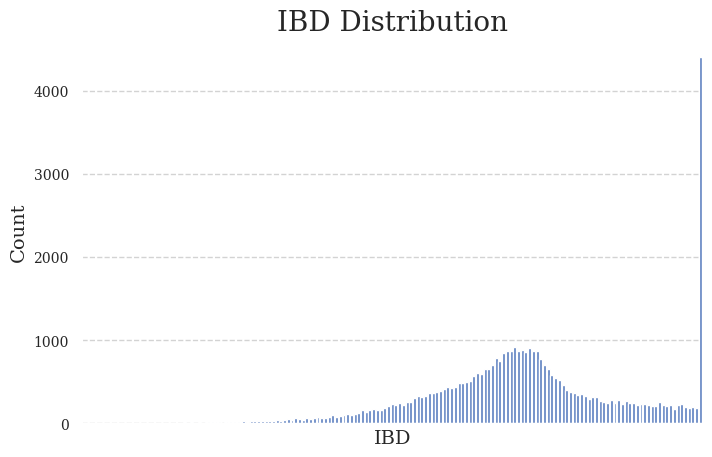

In [43]:
# plot the IBD distribution
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='IBD')
plt.title('IBD Distribution')
plt.xlabel('IBD')
plt.ylabel('Count')
plt.xticks([])
plt.show()

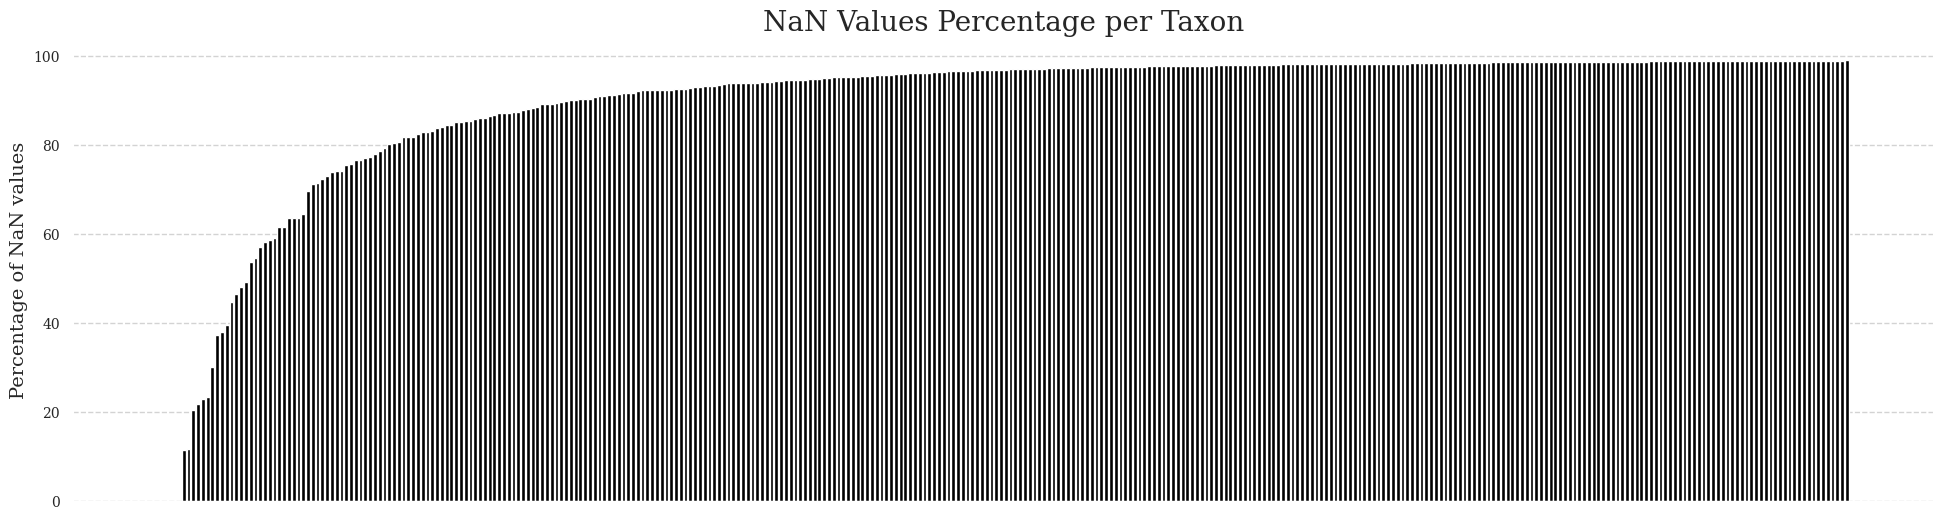

In [6]:
# Create a plot of NaN percentages per column
import matplotlib.pyplot as plt

# restart matplotlib
from scripts import style
style.mpl_apply()

plt.figure(figsize=(24, 6))
plt.bar(vals.index, vals.values, color='black')
plt.xticks(rotation=90)
plt.ylabel('Percentage of NaN values')
plt.title('NaN Values Percentage per Taxon')
# dont show x axis labels
plt.xticks([])
plt.show()


In [7]:
# display some rows
pd.set_option("display.max_columns", 8)
df

,SamplingOperations_code,Date_SamplingOperation,TotalAbundance_SamplingOperation,Achaf02,...,Vibtr01,Longitude_Lambert93,Latitude_Lambert93,IBD
2703,S02115200_20070702,2007-07-02,400,NaN,...,NaN,902925.0,6941112.0,10.5
33984,S05218450_20070709,2007-07-09,400,NaN,...,NaN,442885.0,6199880.0,20.0
33929,S05217350_20070709,2007-07-09,400,NaN,...,NaN,442250.0,6218040.0,20.0
48228,S05235850_20070709,2007-07-09,400,NaN,...,2.500000,463192.0,6225280.0,NaN
35408,S05234290_20070709,2007-07-09,400,NaN,...,10.000000,456573.0,6224410.0,16.6
...,...,...,...,...,...,...,...,...,...
42720,S06580577_20230907,2023-09-07,426,NaN,...,4.694836,908596.0,6499943.0,14.5
35760,S06001284_20230907,2023-09-07,421,NaN,...,87.885986,910629.0,6500149.0,16.3
35783,S06001533_20230907,2023-09-07,401,NaN,...,62.344140,909322.0,6499820.0,14.8
38878,S06137040_20231011,2023-10-11,400,NaN,...,10.000000,967828.0,6518569.0,20.0


In [28]:
# select the desired columns correctly using a list of column names
ibd = df_copy[['SamplingOperations_code', 'CodeSite_SamplingOperations_x', 'Date_SamplingOperation', 'Longitude_Lambert93', 'Latitude_Lambert93', 'IBD']]
ibd = ibd.set_index('SamplingOperations_code', inplace=False)
ibd

,CodeSite_SamplingOperations_x,Date_SamplingOperation,Longitude_Lambert93,Latitude_Lambert93,IBD
SamplingOperations_code,,,,,
S02115200_20070702,S02115200,2007-07-02,902925.0,6941112.0,10.5
S05218450_20070709,S05218450,2007-07-09,442885.0,6199880.0,20.0
S05217350_20070709,S05217350,2007-07-09,442250.0,6218040.0,20.0
S05235850_20070709,S05235850,2007-07-09,463192.0,6225280.0,NaN
S05234290_20070709,S05234290,2007-07-09,456573.0,6224410.0,16.6
...,...,...,...,...,...
S06580577_20230907,S06580577,2023-09-07,908596.0,6499943.0,14.5
S06001284_20230907,S06001284,2023-09-07,910629.0,6500149.0,16.3
S06001533_20230907,S06001533,2023-09-07,909322.0,6499820.0,14.8


# Rapids

In [9]:
# conda:  conda create -n rapids -c rapidsai -c conda-forge rapids=24.08 python=3.10 cuda-version=12.2
import cupy as cp, cudf

In [10]:
import cupy as cp, cudf
# cudf means GPU DataFrame, to install you must follow the instructions at
# https://rapids.ai/start.html#get-rapids
from cuml.neighbors import NearestNeighbors
import numpy as np, pandas as pd

In [29]:
# ====================== Space–Time Interpolation (GPU w/ CPU fallback) ======================
# Requirements:
# - CPU path: numpy, pandas, scikit-learn
# - GPU path (optional): cupy, cuml (RAPIDS). If unavailable, CPU path is used automatically.

import numpy as np
import pandas as pd

# ---------- utilities ----------

def _to_days(s: pd.Series) -> np.ndarray:
    """Convert datelike series to int days since epoch (float32)."""
    return np.asarray(pd.to_datetime(s), dtype='datetime64[D]').astype('int64').astype(np.float32)

def _apply_metric_xy(xy: np.ndarray, M: np.ndarray | None) -> np.ndarray:
    """Apply anisotropy metric M (2x2 SPD) to XY via Cholesky. If None, identity."""
    if M is None:
        return xy.astype(np.float32, copy=False)
    L = np.linalg.cholesky(M.astype(np.float32))
    return (xy @ L.T).astype(np.float32, copy=False)

def robust_alpha(
    x: np.ndarray, y: np.ndarray, t_days: np.ndarray, *,
    site_id: np.ndarray | None = None,
    k: int = 6, q_spatial: float = 0.5, q_temporal: float = 0.5,
    floor_alpha: float = 1e-6
) -> np.float32:
    """
    Robust time-vs-space scale:
        alpha ~= (spatial_range / temporal_range)^2
    - spatial_range from UNIQUE sites only, ignoring zero distances
    - temporal_range from POSITIVE within-site gaps
    """
    from sklearn.neighbors import NearestNeighbors

    xy_all = np.c_[x.astype(np.float32), y.astype(np.float32)]

    # --- spatial range: use unique sites (rounded to 1 m) ---
    xy_unique = np.unique(np.round(xy_all, 0), axis=0)
    if xy_unique.shape[0] >= 2:
        nn = NearestNeighbors(n_neighbors=min(k, xy_unique.shape[0])).fit(xy_unique)
        D = nn.kneighbors(return_distance=True)[0][:, 1:]  # drop self
        Dpos = D[D > 0]
        if Dpos.size:
            r_s = float(np.quantile(Dpos, q_spatial))
        else:
            dx, dy = (xy_unique.max(0) - xy_unique.min(0))
            r_s = float(np.hypot(dx, dy) / max(1, np.sqrt(xy_unique.shape[0])))
    else:
        r_s = 1.0

    # --- temporal range: positive gaps within sites ---
    if site_id is None:
        # crude hash if no site id provided
        site_id = (np.round(x, 0).astype(np.int64) << 21) + np.round(y, 0).astype(np.int64)

    gaps_pos = []
    df_tmp = pd.DataFrame({"site": site_id, "t": t_days.astype(np.int64)})
    for _, g in df_tmp.groupby("site", sort=False):
        tt = np.sort(np.unique(g["t"].values))
        d = np.diff(tt)
        d = d[d > 0]
        if d.size:
            gaps_pos.append(d)
    if gaps_pos:
        gaps_all = np.concatenate(gaps_pos)
        r_t = float(np.quantile(gaps_all, q_temporal))
    else:
        r_t = 1.0

    if r_t <= 0:
        r_t = 1.0

    alpha = (r_s / r_t) ** 2
    return np.float32(max(alpha, floor_alpha))

# ---------- main API ----------

def fill_missing_space_time(
    df: pd.DataFrame,
    *,
    target_col: str,                 # column to fill (e.g., "IBD")
    date_col: str,                   # date column
    xy_cols: tuple[str, str],        # (x_col, y_col) in meters (e.g., Lambert93)
    site_col: str | None = None,     # optional site ID column to improve temporal gap calc
    alpha: float | None = None,      # None => robustly estimated; or pass a fixed value (e.g., 128.0)
    M: np.ndarray | None = None,     # 2x2 SPD metric for spatial anisotropy; None => isotropic
    k: int = 48,                     # neighbors
    batch: int = 200_000,            # query batch size
    kernel: str = "gaussian",        # "gaussian" | "imq" | "linear"
    kernel_eps: float | None = None, # None => auto from neighbor dists
    query_mask: pd.Series | None = None,  # rows to fill; default: NaNs in target_col
    prefer_gpu: bool = True,         # try RAPIDS first
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Fill only NaNs of `target_col` using space–time kNN kernel smoothing in (x, y, sqrt(alpha)*t).
    GPU (RAPIDS cuML + CuPy) if available, else CPU. All math in float32.
    """
    out = df.copy()

    # define train/query
    if query_mask is None:
        query_mask = out[target_col].isna()
    train_mask = out[target_col].notna()

    if not np.any(query_mask.values):
        if verbose: print("Nothing to fill; no NaNs in target.")
        return out

    # assemble arrays (float32)
    x = out[xy_cols[0]].astype(np.float32).to_numpy()
    y = out[xy_cols[1]].astype(np.float32).to_numpy()
    xy = np.c_[x, y].astype(np.float32)
    xy = _apply_metric_xy(xy, M)

    t_days = _to_days(out[date_col])
    z_tr   = out.loc[train_mask, target_col].astype(np.float32).to_numpy()

    XY_tr  = xy[train_mask.values]
    T_tr   = t_days[train_mask.values]
    XY_q   = xy[query_mask.values]
    T_q    = t_days[query_mask.values]

    # optional site ids
    site_id_all = out[site_col].to_numpy() if site_col is not None else None
    site_id_tr  = site_id_all[train_mask.values] if site_id_all is not None else None

    # alpha
    if alpha is None:
        alpha32 = robust_alpha(
            x=XY_tr[:, 0], y=XY_tr[:, 1], t_days=T_tr,
            site_id=site_id_tr, k=6, q_spatial=0.5, q_temporal=0.5, floor_alpha=1e-6
        )
    else:
        alpha32 = np.float32(alpha)

    Ts_tr = np.sqrt(alpha32, dtype=np.float32) * T_tr
    Ts_q  = np.sqrt(alpha32, dtype=np.float32) * T_q

    if verbose:
        # diagnostics
        # estimate robust ranges for printing (not used later)
        try:
            from sklearn.neighbors import NearestNeighbors
            xy_unique = np.unique(np.round(XY_tr, 0), axis=0)
            if xy_unique.shape[0] >= 2:
                Dsp = NearestNeighbors(n_neighbors=min(6, xy_unique.shape[0])).fit(xy_unique)\
                        .kneighbors(return_distance=True)[0][:,1:]
                r_s = float(np.median(Dsp[Dsp > 0])) if (Dsp > 0).any() else 1.0
            else:
                r_s = 1.0
        except Exception:
            r_s = float('nan')
        # temporal median gap
        r_t = 1.0
        if site_id_tr is not None:
            gaps = []
            df_tmp = pd.DataFrame({"site": site_id_tr, "t": T_tr.astype(np.int64)})
            for _, g in df_tmp.groupby("site", sort=False):
                tt = np.sort(np.unique(g["t"].values))
                d = np.diff(tt); d = d[d > 0]
                if d.size: gaps.append(d)
            if gaps: r_t = float(np.median(np.concatenate(gaps)))
        else:
            tt = np.sort(np.unique(T_tr.astype(np.int64)))
            d = np.diff(tt); d = d[d > 0]
            if d.size: r_t = float(np.median(d))

        print(f"Estimated spatial range r_s ≈ {r_s:.1f} m")
        print(f"Estimated temporal range r_t ≈ {r_t:.1f} days")
        print(f"Using alpha = {alpha32:.6g}")

    # ------------ GPU path ------------
    used_gpu = False
    if prefer_gpu:
        try:
            import cupy as cp
            from cuml.neighbors import NearestNeighbors as cuKNN

            Xtr = cp.asarray(np.c_[XY_tr, Ts_tr])   # (n,3) float32
            ytr = cp.asarray(z_tr)

            knn = cuKNN(n_neighbors=k, algorithm="brute", metric="euclidean")
            knn.fit(Xtr)

            # epsilon (kernel scale)
            if kernel_eps is None:
                m = int(min(5000, Xtr.shape[0]))
                idx = cp.random.permutation(Xtr.shape[0])[:m]
                Dp, _ = knn.kneighbors(Xtr[idx], return_distance=True)
                eps = float(cp.median(Dp[:, 1:]).item())
            else:
                eps = float(kernel_eps)

            def _weights_gpu(D):
                U = D / eps
                if kernel == "gaussian":
                    return cp.exp(-(U * U))
                if kernel == "imq":   # inverse multiquadric
                    return 1.0 / cp.sqrt(1.0 + U * U)
                if kernel == "linear":
                    return cp.maximum(1.0 - U, 0.0)
                raise ValueError("kernel must be gaussian|imq|linear")

            preds = np.empty_like(Ts_q, dtype=np.float32)
            for s in range(0, len(Ts_q), batch):
                e = min(s + batch, len(Ts_q))
                Xq = cp.asarray(np.c_[XY_q[s:e], Ts_q[s:e]])
                D, I = knn.kneighbors(Xq, return_distance=True)   # (B,k)
                W    = _weights_gpu(D)
                Wsum = cp.maximum(W.sum(axis=1, keepdims=True), 1e-12)
                znei = ytr[I]
                zhat = (W * znei).sum(axis=1) / Wsum.squeeze()
                preds[s:e] = cp.asnumpy(zhat)
                del Xq, D, I, W, Wsum, znei, zhat
                cp.get_default_memory_pool().free_all_blocks()

            out.loc[query_mask, target_col] = preds.astype(np.float32)
            used_gpu = True
            if verbose: print("Filled with GPU (RAPIDS).")

        except Exception as ex:
            used_gpu = False
            if verbose: print(f"GPU path unavailable or failed ({type(ex).__name__}). Falling back to CPU.")

    # ------------ CPU fallback ------------
    if not used_gpu:
        from sklearn.neighbors import NearestNeighbors
        Xtr = np.c_[XY_tr, Ts_tr].astype(np.float32)
        knn = NearestNeighbors(n_neighbors=k, algorithm="auto", metric="euclidean").fit(Xtr)

        if kernel_eps is None:
            m = int(min(5000, Xtr.shape[0]))
            probe_idx = np.random.permutation(Xtr.shape[0])[:m]
            Dp, _ = knn.kneighbors(Xtr[probe_idx], return_distance=True)
            eps = float(np.median(Dp[:, 1:]))
        else:
            eps = float(kernel_eps)

        def _weights_cpu(D):
            U = D / eps
            if kernel == "gaussian":
                return np.exp(-(U * U)).astype(np.float32, copy=False)
            if kernel == "imq":
                return (1.0 / np.sqrt(1.0 + U * U)).astype(np.float32, copy=False)
            if kernel == "linear":
                return np.maximum(1.0 - U, 0.0).astype(np.float32, copy=False)
            raise ValueError("kernel must be gaussian|imq|linear")

        preds = np.empty_like(Ts_q, dtype=np.float32)
        Xq_all = np.c_[XY_q, Ts_q].astype(np.float32)
        for s in range(0, len(Ts_q), batch):
            e = min(s + batch, len(Ts_q))
            D, I = knn.kneighbors(Xq_all[s:e], return_distance=True)
            W    = _weights_cpu(D)
            Wsum = np.maximum(W.sum(axis=1, keepdims=True), 1e-12)
            znei = z_tr[I]
            preds[s:e] = (W * znei).sum(axis=1) / Wsum.squeeze()

        out.loc[query_mask, target_col] = preds.astype(np.float32)
        if verbose: print("Filled with CPU.")

    return out

# ====================== Example usage ======================
filled = fill_missing_space_time(
    ibd,
    target_col="IBD",
    date_col="Date_SamplingOperation",
    xy_cols=("Longitude_Lambert93","Latitude_Lambert93"),
    site_col="CodeSite_SamplingOperations_x",  # optional, improves temporal gaps if available
    alpha=None,               # or set e.g. alpha=128.0 to lock behavior
    M=None,                   # or provide 2x2 SPD metric for spatial anisotropy
    k=48,
    batch=200_000,
    kernel="gaussian",        # "gaussian" | "imq" | "linear"
    kernel_eps=None,          # auto
    prefer_gpu=True,
    verbose=True
)


Estimated spatial range r_s ≈ 7393.9 m
Estimated temporal range r_t ≈ 373.0 days
Using alpha = 392.938
Filled with GPU (RAPIDS).


# Notes

In [44]:
from scripts import latex2md

import pyperclip

pyperclip.copy(latex2md.latex_to_markdown(pyperclip.paste()))

# Is it better to leave the NaNs?

Yes—start by predicting IBD **directly with XGBoost**, leaving taxa NaNs as-is. XGBoost routes NaNs automatically and you avoid imputation bias. Then add structure only if it improves CV.

# Plan (ranked by leverage)

1. **Baseline XGB** (no imputation).
   Inputs:

   * Taxa columns as is.
   * `TotalAbundance_SamplingOperation`.
   * Space–time features: `x`, `y`, `sin/cos(2π·month)`, `year`, watershed dummies.
   * Optional: log1p of counts and row-wise proportions.
     CV: **forward-time within site** + **spatial block**.

2. **Feature pruning** (no imputation).

   * Keep taxa with prevalence ≥ 5–10
   * Optionally collapse to genus for ultra-rare taxa.
   * Add **presence flags** `1{taxon observed}` as separate sparse features.

3. **Hybrid** (only if CV improves):

   * Train XGB; compute residuals; smooth residuals in ((x,y,t)) with your GPU kNN kernel; final = XGB + residual smoother.

4. **Only if needed**: targeted imputation for **mid-prevalence** taxa (10–30


# Decision rule

* If baseline XGB (no imputation) **wins** in forward-time + spatial-block CV → keep it.
* If residual smoother **reduces MAE/RMSE** materially (≥5–10
* Impute taxa only if a **small subset** are mid-prevalence and clearly predictive.

# Limits

Direct XGB can underfit sharp local anomalies; the residual smoother handles that. Full-taxonomic imputation risks inventing taxa and breaking compositional totals.
$$
\boxed{\textbf{Best default: } \text{XGB on raw taxa + space–time features; add residual smoothing only if CV shows a gain.}}
$$


## What is spatial anisotropy metric (M)

(M) is the **spatial anisotropy metric**. It tells the interpolator how to *measure distance in (x!-!y) space* before mixing with time.

## Definition

* $M\in\mathbb{R}^{2\times2}$ symmetric positive definite (SPD).
* Spatial part of the space–time distance:
$$
  r^2=\underbrace{(\mathbf{s}-\mathbf{s}_i)^\top M,(\mathbf{s}-\mathbf{s}*i)}*{\text{spatial metric}}+\alpha,(t-t_i)^2.
$$
* If $M=I$: isotropic. One meter east = one meter north.

## Why use it

Real fields often correlate *farther* along one direction (e.g., along a river) than across it. (M) stretches/rotates the coordinate system so the kernel “sees” that:

* Longer range along flow ⇒ **shrink** distance along that axis (smaller weight in (M)).
* Shorter range across flow ⇒ **expand** distance across that axis (larger weight in (M)).

## Parameterization

Pick principal axes: long-range $a_\parallel$ and short-range $a_\perp$ (meters), rotated by angle $\theta$ from the (x)-axis.

* Rotation $R(\theta)=\begin{bmatrix}\cos\theta&-\sin\theta\ \sin\theta&\cos\theta\end{bmatrix}$.
* Axis scales $D=\mathrm{diag}(a_\parallel^{-2},,a_\perp^{-2})$.
* Metric:
$$
  \boxed{,M=R(\theta),D,R(\theta)^\top,}
$$
Interpretation: distances along the long axis are divided by $a_\parallel$; across, by $a_\perp$. Larger (a) ⇒ slower decay along that direction.

## How to choose $a_\parallel,a_\perp,\theta$

1. **From data**: compute directional variograms or kNN ranges in angle bins; fit ellipse of correlation.
2. **From domain knowledge**: river bearing $=\theta$; choose $a_\parallel!\gg!a_\perp$ (e.g., 50 km vs 5 km).
3. **If unsure**: use $M=I$ (isotropic), then refine after diagnostics.

## Minimal code

```python
import numpy as np

def metric_from_anisotropy$a_parallel, a_perp, theta_rad$:
    c, s = np.cos$theta_rad$, np.sin$theta_rad$
    R = np.array$[[c, -s],[s, c]], dtype=np.float32$
    D = np.diag$[1.0/(a_parallel**2), 1.0/(a_perp**2)]$.astype$np.float32$
    return (R @ D @ R.T).astype$np.float32$

# examples:
# isotropic  -> M = I
M_iso = np.eye$2, dtype=np.float32$

# river-aligned anisotropy:  theta=river bearing (rad), range 30 km along, 5 km across
M_river = metric_from_anisotropy$30_000.0, 5_000.0, theta_rad$
```

## Where it plugs in (your function)

Pass `M` to `fill_missing_space_time(...)`. Internally we Cholesky-factor (M) and map $\tilde{\mathbf{s}}=L,\mathbf{s}$; then Euclidean distance in $\tilde{\mathbf{s}}$ equals $\sqrt{(\mathbf{s}-\mathbf{s}_i)^\top M(\mathbf{s}-\mathbf{s}_i)}$.

## When to leave it as identity

* No clear directional structure.
* Sparse data where estimating anisotropy is unreliable.
* Early baselines; add (M) after you validate a benefit.
$$
\boxed{\text{Set }M=R(\theta),\mathrm{diag}(a_\parallel^{-2},a_\perp^{-2}),R(\theta)^\top;; M=I \text{ if isotropic.}}
$$


## Reliable kNN interpolation with NaN targets

Yes, it works **iff** each query has enough non-NaN neighbors. If training density is low, predictions get unstable. Solve with a **backoff ladder** and **coverage guards**.

## What changes

* Keep training set = rows with target not NaN.
* For each query $q=(x,y,\sqrt\alpha t)$, require an **effective neighbor count**:
$$
  n_{\mathrm{eff}}=\frac{(\sum_i w_i)^2}{\sum_i w_i^2}\quad(\text{needs }n_{\mathrm{eff}}\ge m).
$$
* If $n_{\mathrm{eff}}<m$, **expand** then **fallback**.

## Practical rules

1. Start with $k_0$ neighbors.
2. If $n_{\mathrm{eff}}<m$: increase $k\to k'$ and/or inflate $\epsilon$.
3. If still low: **relax time** $halve (\alpha)$ to pull more cross-time neighbors.
4. If still low: fallback sequence
   a) same-site temporal kernel only,
   b) spatial-only on closest day(s) $|Δt| ≤ Δt_{max}$,
   c) group median (e.g., same HERlvl1),
   d) leave NaN.

## GPU-side tweaks (drop-in for your function)

* Add `min_neff`, `k_max`, `alpha_relax=0.25`, `dt_max_days`.
* After `kneighbors`, compute $n_{\mathrm{eff}}$. If low, re-query with bigger `k` or modified $\alpha$.
* Implement temporal-only and spatial-only branches using the same GPU kNN on 1D (t) or 2D ((x,y)).

## Heuristics

* `min_neff` ≈ 8–12.
* `k0=32`, `k_max=128`.
* If missing rate >70

## Sanity checks

* Log share of predictions by mode: main vs expanded vs fallbacks.
* Plot error by $n_{\mathrm{eff}}$; expect monotone decay.
* If many fallbacks hit group medians, your variable is under-observed; reconsider data collection or use a supervised model.
$$
\boxed{\hat f(q)=\frac{\sum_{i\in\mathcal{N}*k(q)}w_i y_i}{\sum w_i};\text{if }n*{\mathrm{eff}}\ge m;;\text{else expand/relax/fallback}}
$$
